In [2]:
import os
import pandas as pd

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
data_path = os.path.join(PROJECT_ROOT, "data", "stock_data.csv")

df = pd.read_csv(data_path, index_col=0, parse_dates=True)

# sadece Close kolonlarını al
close_cols = [c for c in df.columns if "Close" in c]
df_close = df[close_cols].copy()

# kolonları tickerlara rename et
tickers = ["AAPL", "AMZN", "GOOG", "MSFT", "TSLA"]
df_close.columns = tickers

# numeric ve temizleme
df_close = df_close.apply(pd.to_numeric, errors="coerce").dropna(how="any")

df = df_close
df.head()


C:\Users\esram\AppData\Local\Temp\ipykernel_10776\2885084137.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(data_path, index_col=0, parse_dates=True)


,AAPL,AMZN,GOOG,MSFT,TSLA
Price,,,,,
2018-01-02,40.341896,59.450500,52.853588,79.050400,21.368668
2018-01-03,40.334846,60.209999,53.721085,79.418274,21.150000
2018-01-04,40.522213,60.479500,53.915630,80.117271,20.974667
2018-01-05,40.983566,61.457001,54.701225,81.110580,21.105333
2018-01-08,40.831356,62.343498,54.934975,81.193336,22.427334


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pmdarima import auto_arima

def auto_arima_forecast(ts: pd.Series, forecast_steps: int = 30):
    model = auto_arima(
        ts,
        seasonal=False,
        stepwise=True,
        suppress_warnings=True,
        error_action="ignore"
    )
    forecast = model.predict(n_periods=forecast_steps)

    forecast_index = pd.date_range(
        start=ts.index[-1] + pd.Timedelta(days=1),
        periods=forecast_steps,
        freq="B"
    )
    return model, pd.Series(forecast, index=forecast_index)


AAPL - test length: 252 | forecast length: 252
AMZN - test length: 252 | forecast length: 252
GOOG - test length: 252 | forecast length: 252
MSFT - test length: 252 | forecast length: 252
TSLA - test length: 252 | forecast length: 252
           RMSE      MAPE      Order
AAPL   16.51912  0.058867  (0, 1, 0)
AMZN  15.277963  0.059201  (0, 1, 0)
GOOG  17.612389  0.064751  (5, 2, 0)
MSFT  22.930738  0.040768  (0, 1, 1)
TSLA  38.965721  0.094137  (0, 1, 0)


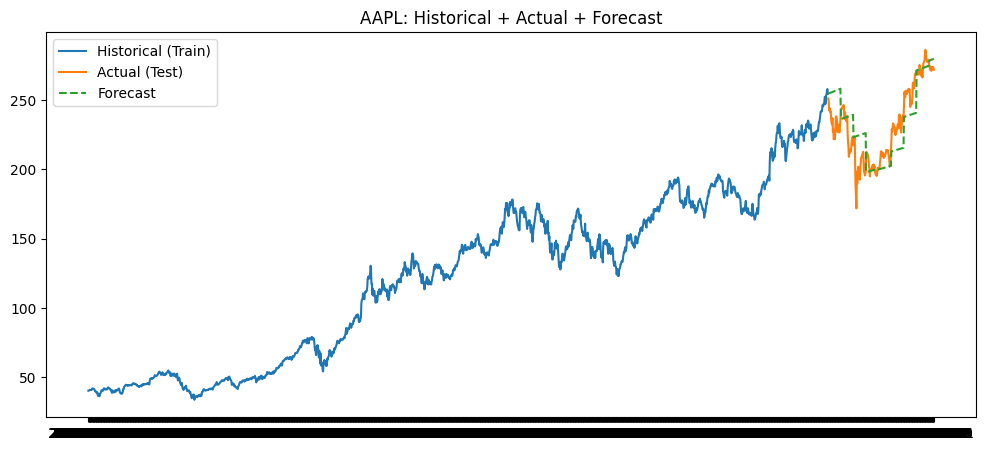

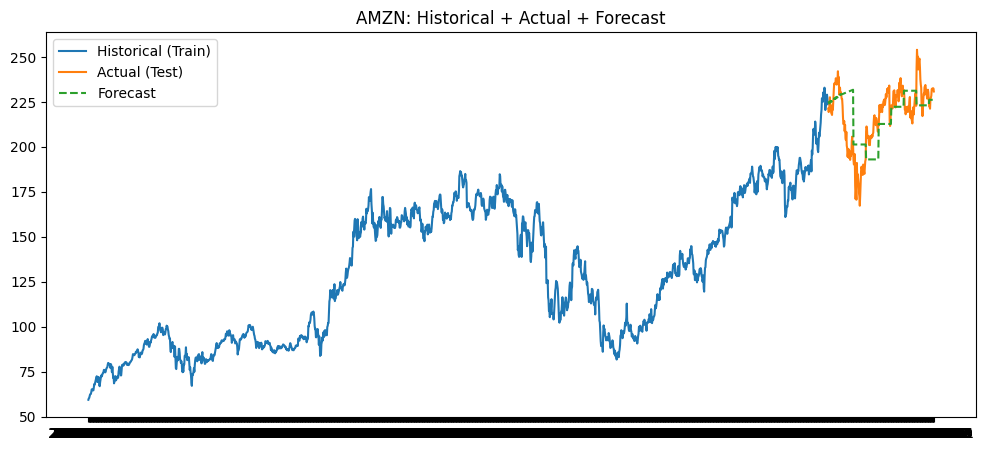

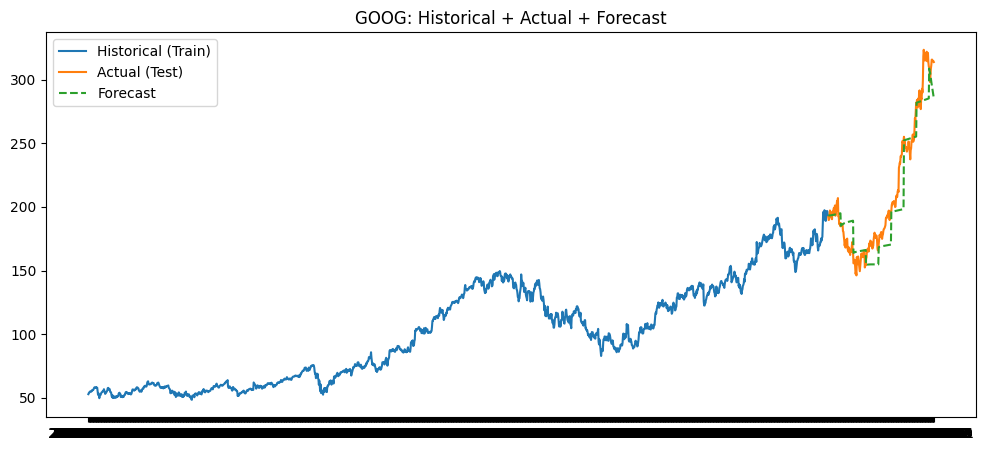

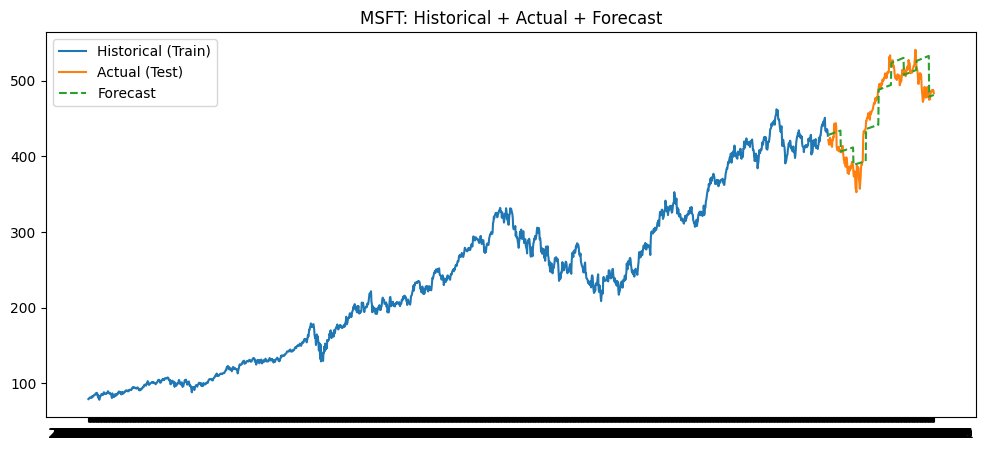

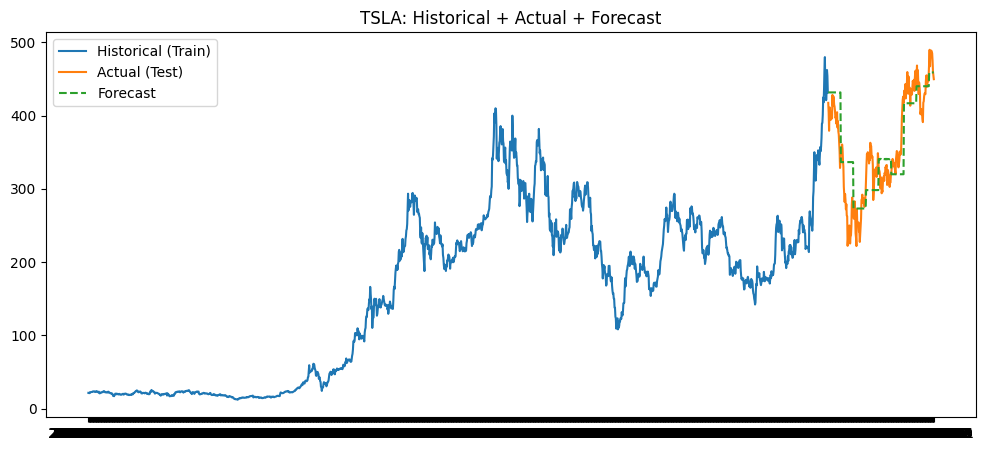

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

def auto_arima_forecast(ts, n_periods=30):
    model = auto_arima(
        ts,
        seasonal=False,
        stepwise=True,
        suppress_warnings=True,
        error_action="ignore"
    )
    forecast = model.predict(n_periods=n_periods)
    return model, forecast

def rolling_forecast_arima(df, forecast_horizon=30, test_days=252):
    results = {}

    for ticker in df.columns:
        ts = df[ticker].dropna()

        train = ts[:-test_days]
        test = ts[-test_days:]

        forecasts = []
        dates = []

        # rolling forecast
        for start in range(0, len(test), forecast_horizon):
            end = start + forecast_horizon
            if end > len(test):
                end = len(test)

            n_periods = end - start

            train_window = ts[:len(train) + start]
            test_window = test[start:end]

            model, forecast = auto_arima_forecast(train_window, n_periods=n_periods)

            forecasts.extend(forecast)
            dates.extend(test_window.index)

        # metrics
        print(f"{ticker} - test length: {len(test)} | forecast length: {len(forecasts)}")
        rmse = mean_squared_error(test[:len(forecasts)], forecasts, squared=False)
        mape = mean_absolute_percentage_error(test[:len(forecasts)], forecasts)

        results[ticker] = {
            "model": model,
            "train": train,
            "test": test,
            "dates": dates,
            "forecast": forecasts,
            "rmse": rmse,
            "mape": mape
        }

    return results

# Kullanım
forecast_horizon = 30
test_days = 252

results = rolling_forecast_arima(df, forecast_horizon, test_days)

# Özet tablo
summary = pd.DataFrame({
    ticker: {
        "RMSE": results[ticker]["rmse"],
        "MAPE": results[ticker]["mape"],
        "Order": results[ticker]["model"].order
    }
    for ticker in results
}).T

print(summary)

# Grafik: Historical (train) + Actual (test) + Forecast
for ticker in df.columns:
    r = results[ticker]

    plt.figure(figsize=(12,5))
    plt.plot(r["train"], label="Historical (Train)")
    plt.plot(r["test"], label="Actual (Test)")
    plt.plot(r["dates"], r["forecast"], label="Forecast", linestyle="--")

    plt.title(f"{ticker}: Historical + Actual + Forecast")
    plt.legend()
    plt.show()
